In [22]:
#%pip install ase==3.22.1
#%pip install numpy==1.24.4
#%pip install dscribe==2.5.0
#%pip install scipy

In [ ]:
from ase.io import read
from ase import Atoms
import os
import glob

folder_path = './Brownmillerite/'
file_list = sorted(glob.glob(os.path.join(folder_path, '*POSCAR'))) 

atoms_list = []
stype = []
red = 0
green = 0
blue = 0
for struc in file_list:
    if "3C" in struc:
        stype.append("red")
        red += 1
    elif "6H" in struc:
        stype.append("black") 
        green += 1
    elif "12R" in struc:
        stype.append("blue")  
        blue +=1
    else:
        print("Found undefind")
        break
    atoms = read(struc,format='vasp')
    atoms_list.append(atoms)
    #supercell = atoms.repeat((2, 1, 1))
    #atoms_list.append(supercell)
    #print(f"Loaded: {struc}")
n_struc = len(atoms_list)
print(f"Total files loaded: {n_struc}")
print(f"3C = {red}")
print(f"6H = {green}")
print(f"12R = {blue}")
print(f"stype loaded {len(stype)} items")


In [ ]:
#Parameters setting
r_cut=5
n_max=2
l_max=2
print(atoms[0])

Atom('Sr', [3.4548621409840216e-08, -0.25944047007731696, 10.185116165385109], index=0)


In [ ]:
species = list(set(atoms.get_chemical_symbols()))
print(species)

['O', 'Co', 'Sr']


# Create average vector for each substance

In [ ]:
import numpy as np
from dscribe.descriptors import SOAP
from ase import Atoms

energy = []
soap_vectors = []
all_atoms = []

average_soap = SOAP(
    species=species,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    average="inner",
    sparse=False,
    periodic=True
)

for cid in atoms_list:
    #print(cid)
    try:
        atoms = cid
    except KeyError:
        print(f"CID {cid} not found, skip")
        continue
    soap_vectors.append(average_soap.create(atoms))
    #all_atoms.append(atoms)
soap_array = np.array(soap_vectors)

In [ ]:
atoms_bm_standrad = read("./SrCoO3.poscar")
average_bm = average_soap.create(atoms_bm_standrad)

In [ ]:
from ase.io import read
from scipy.spatial.distance import euclidean, cosine
import numpy as np

import math

def cos_sim(p, q):
    return 1-(np.dot(p, q) / (np.linalg.norm(p) * np.linalg.norm(q)))

third_smallest = 0
second_smallest = 0
smallest = 0
    
# 1. Read the standard structure and generate its SOAP vector
atoms_bm_standard = read("./SrCoO3.poscar")
average_bm = average_soap.create(atoms_bm_standard)

# 2. Iterate through soap_array (a list or array of SOAP vectors)
euclidean_distances = []
cosine_similarities = []
close_to_BM = []
close_to_BM_ID = []

for i, soap_vec in enumerate(soap_array):
    # Ensure vectors are flattened if necessary
    vec = np.ravel(soap_vec)
    ref = np.ravel(average_bm)

    # Euclidean distance
    euclid = euclidean(ref, vec)
    euclidean_distances.append(euclid)

    cosine_sim = cos_sim(ref, vec)
    cosine_similarities.append(cosine_sim)
    
    if euclid < 90 and cosine_sim < 0.002:
        close_to_BM.append(soap_vec)
        close_to_BM_ID.append(i)
        print(file_list[i])


# Optional: Convert to NumPy arrays for easy plotting/processing
euclidean_distances = np.array(euclidean_distances)
cosine_similarities = np.array(cosine_similarities)

# Example output
print(len(euclidean_distances))
print(len(cosine_similarities))
print(len(close_to_BM))


IndentationError: expected an indented block after 'if' statement on line 15 (1393507597.py, line 16)

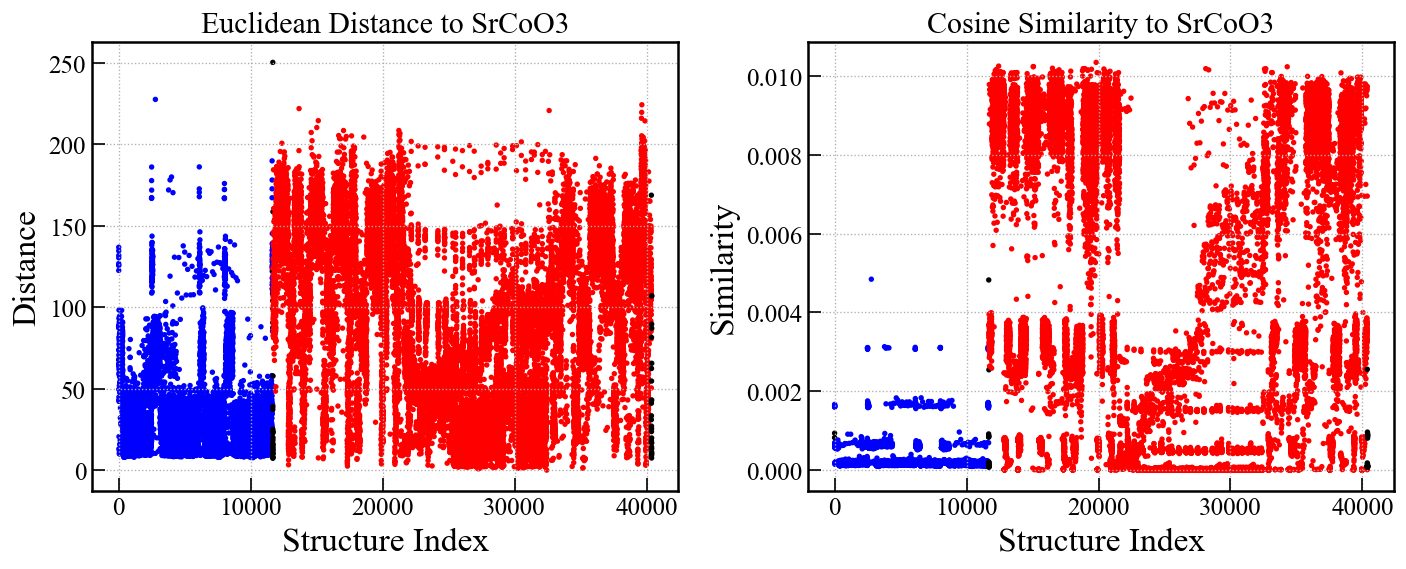

In [ ]:
import matplotlib.pyplot as plt

x = np.arange(len(euclidean_distances))  # 各構造のインデックス

plt.figure(figsize=(12, 5))

# 1. Euclidean Distance
plt.subplot(1, 2, 1)
plt.scatter(x, euclidean_distances, marker='o', c=stype,s=5)
plt.title('Euclidean Distance to SrCoO3')
plt.xlabel('Structure Index')
plt.ylabel('Distance')
plt.grid(True)

# 2. Cosine Similarity
plt.subplot(1, 2, 2)
plt.scatter(x, cosine_similarities, marker='o', c=stype,s=5)
plt.title('Cosine Similarity to SrCoO3')
plt.xlabel('Structure Index')
plt.ylabel('Similarity')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
def smallest(arr):
  smallest_val = float('inf')
  second_smallest_val = float('inf')
  third_smallest_val = float('inf')

  smallest_idx = -1
  second_smallest_idx = -1
  third_smallest_idx = -1

  # Loop through the list to get both index (i) and value (number)
  for i, number in enumerate(arr):
    if number < smallest_val:
      # Shift existing values and indices down
      third_smallest_val = second_smallest_val
      third_smallest_idx = second_smallest_idx

      second_smallest_val = smallest_val
      second_smallest_idx = smallest_idx

      smallest_val = number
      smallest_idx = i

    elif number < second_smallest_val:
      # Update second and third smallest
      third_smallest_val = second_smallest_val
      third_smallest_idx = second_smallest_idx

      second_smallest_val = number
      second_smallest_idx = i

    elif number < third_smallest_val:
      # Update only the third smallest
      third_smallest_val = number
      third_smallest_idx = i

  # Collect the valid indices found
  result_indices = [idx for idx in [smallest_idx, second_smallest_idx, third_smallest_idx] if idx != -1]

  return result_indices

print("Euclid ranking:")
for i in smallest(euclidean_distances):
  print(file_list[i])

print("Cosine ranking:")
for i in smallest(cosine_similarities):
  print(file_list[i])
print(smallest(euclidean_distances))
print(smallest(cosine_similarities))

Euclid ranking:¥n
./Brownmillerite/3C_28681_POSCAR
./Brownmillerite/3C_24009_POSCAR
./Brownmillerite/3C_24071_POSCAR
Cosine ranking:¥n
./Brownmillerite/3C_28681_POSCAR
./Brownmillerite/3C_26769_POSCAR
./Brownmillerite/3C_26694_POSCAR
[32440, 27250, 27319]
[32440, 30315, 30232]


# UMAP

In [ ]:
import matplotlib.pyplot as plt

rcParams_dict = {
    # ---------- figure
    'figure.figsize': [8, 6],
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    # ---------- axes
    'axes.grid': True,
    'axes.linewidth': 1.5,
    # ---------- ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 8.0,
    'ytick.major.size': 8.0,
    # ---------- lines
    'lines.linewidth': 2.5,
    'lines.markersize': 12,
    # ---------- grid
    'grid.linestyle': ':',
    # ---------- font
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'cm',
    #'mathtext.fontset': 'stix',
    'font.size': 15,
    'axes.labelsize': 20,
    'legend.fontsize': 20,
    'svg.fonttype': 'path',  # Embed characters as paths
    #'svg.fonttype': 'none',  # Assume fonts are installed on the machine
    'pdf.fonttype': 42,  # embed fonts in PDF using type42 (True type)
}

plt.rcParams.update(rcParams_dict)